In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv("weight-height.csv")

In [3]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [4]:
df.shape

(10000, 3)

In [5]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Count'>

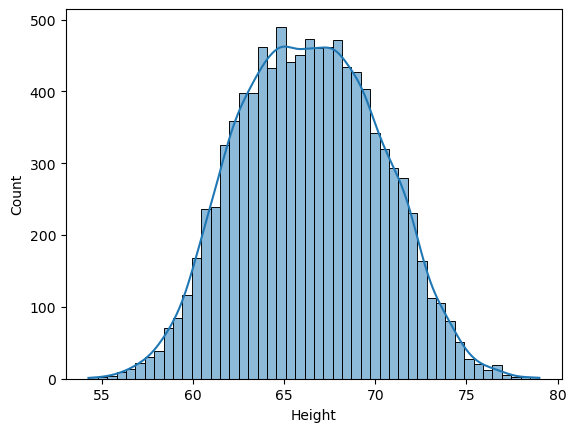

In [6]:
sns.histplot(data=df,x='Height',kde=True)

<Axes: xlabel='Height'>

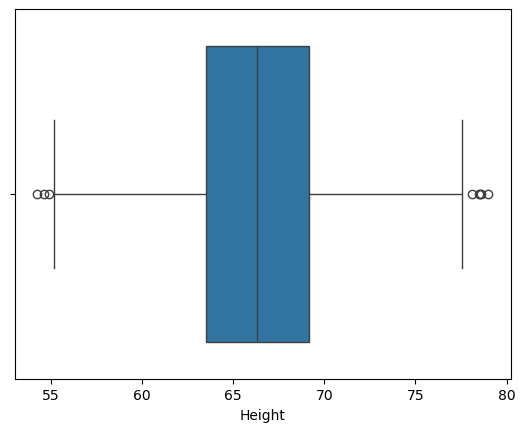

In [7]:
sns.boxplot(data=df,x='Height')

In [8]:
upper_limit=df['Height'].quantile(0.97)
lower_limit=df['Height'].quantile(0.03)

In [9]:
print(upper_limit,lower_limit)

73.46353952182857 59.531091146317436


In [20]:
# Trimming

df[(df['Height']>upper_limit) | (df['Height']<lower_limit)]

,Gender,Height,Weight
0,Male,73.847017,241.893563
2,Male,74.110105,212.740856
23,Male,75.205974,228.761781
31,Male,74.033808,212.910225
62,Male,73.818535,195.290612
...,...,...,...
9929,Female,59.514678,109.421206
9947,Female,59.061703,123.947047
9978,Female,57.375759,114.192209
9984,Female,59.047029,111.707369


In [11]:
new_df=df[(df['Height']<=upper_limit) & (df['Height']>=lower_limit)]

In [12]:
new_df.shape

(9400, 3)

In [13]:
new_df['Height'].describe()

count    9400.000000
mean       66.359917
std         3.378867
min        59.531162
25%        63.706546
50%        66.318070
75%        69.004394
max        73.462805
Name: Height, dtype: float64

In [14]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Count'>

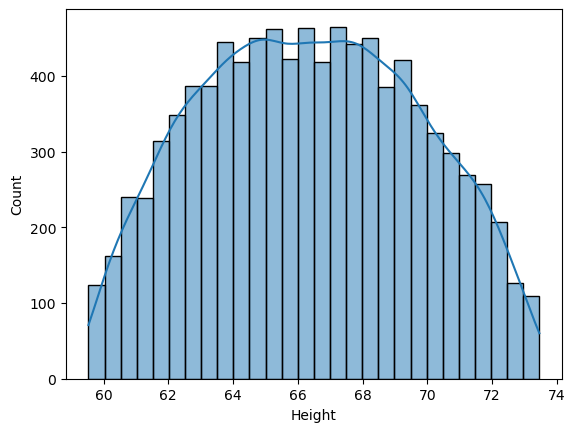

In [15]:
sns.histplot(data=new_df,x='Height',kde=True)

<Axes: xlabel='Height'>

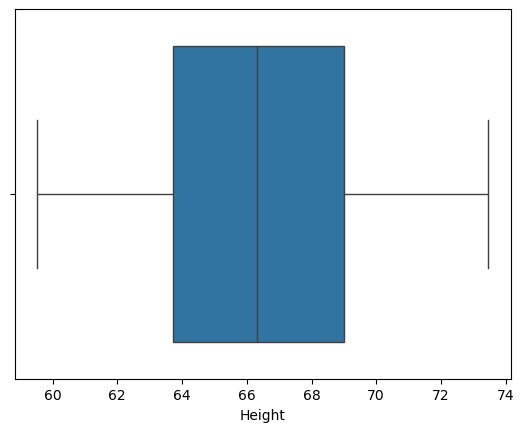

In [16]:
sns.boxplot(data=new_df,x='Height')

In [17]:
new_df['Height'].skew()

np.float64(0.040802022897025114)

In [18]:
df['Height'].skew()

np.float64(0.04936908937689031)

In [27]:
# Capping - winsorization

new_df_cap=df.copy()

new_df_cap['Height']=np.where(
    df['Height']>upper_limit,
    upper_limit,
    np.where(
        df['Height']<lower_limit,
        lower_limit,
        df['Height']
    )
)

In [29]:
new_df_cap['Height'].describe()

count    10000.000000
mean        66.368160
std          3.693876
min         59.531091
25%         63.505620
50%         66.318070
75%         69.174262
max         73.463540
Name: Height, dtype: float64

In [30]:
new_df_cap['Height'].skew()

np.float64(0.046479956585224046)

<Axes: xlabel='Height', ylabel='Count'>

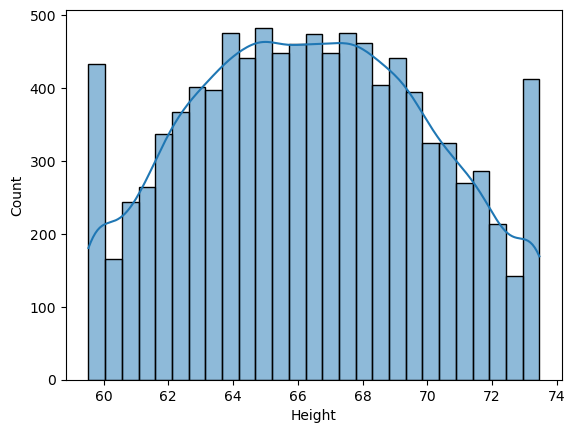

In [31]:
sns.histplot(data=new_df_cap,x='Height',kde=True)

<Axes: xlabel='Height'>

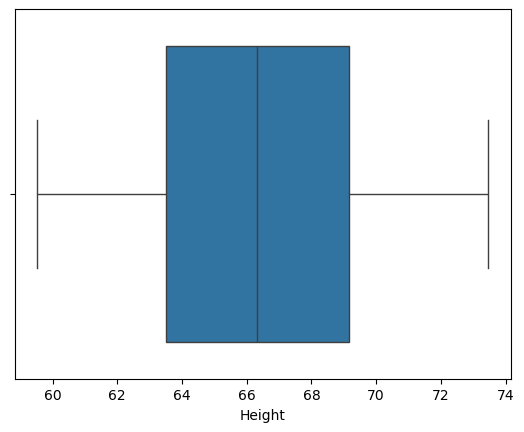

In [32]:
sns.boxplot(data=new_df_cap,x='Height')